# Patient profile creation

In these code snippets i run an example of how we should create the patients profile.

In [1]:
from pathlib import Path
import pandas as pd
notebook_dir = Path().resolve()
FEATURE_PATH = notebook_dir.parents[1] / "Tasks" / "1" / "Features" 
TESTS_FEATURES_NAME = "laboratory_tests_features.csv"
PROCEDURE_FEATURES_NAME = "procedure_code_features.csv"
PATIENT_PROFILES_NAME = "patient_profiles_core.csv"

tests = pd.read_csv(FEATURE_PATH / TESTS_FEATURES_NAME)
procedures = pd.read_csv(FEATURE_PATH / PROCEDURE_FEATURES_NAME)
patient_profiles = pd.read_csv(FEATURE_PATH / PATIENT_PROFILES_NAME)

In [2]:
tests

,hadm_id,total_tests,n_invalid,n_days_span,perc_invalid
0,20004456,79,40,2,0.506329
1,20007905,188,52,3,0.276596
2,20013519,82,28,2,0.341463
3,20013602,58,10,1,0.172414
4,20014999,272,81,7,0.297794
...,...,...,...,...,...
4746,29991470,66,20,3,0.303030
4747,29995484,159,62,3,0.389937
4748,29996728,432,237,14,0.548611
4749,29998994,40,7,1,0.175000


In [3]:
procedures

,hadm_id,total_procedures,unique_procedures,n_days_span
0,20007905,5,5,1
1,20014999,3,3,0
2,20015927,2,2,0
3,20021932,7,7,0
4,20022560,5,5,0
...,...,...,...,...
3454,29968754,6,6,0
3455,29970039,8,8,9
3456,29986749,7,7,3
3457,29998994,6,6,0


In [4]:
patient_profiles

,subject_id,hadm_id,age,gender,icd_code,temperature,bp_systolic,bp_diastolic,heart_rate,respiratory_rate,...,pulmonary_hypertension,wall_motion_abnormality,low_cardiac_output,st_elevation,lbbb,pleural_effusion,pulmonary_edema,pericardial_effusion,heart_failure_severity_score,risk_category
0,10000980,29654838,75.0,F,I50,98.1,200.0,103.0,65.0,26.0,...,1.0,0.0,NaN,0.0,0.0,NaN,NaN,0.0,0,Low
1,10000980,26913865,75.0,F,I21,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,NaN,NaN,NaN,0.0,1.0,0.0,1,Low
2,10002013,24760295,NaN,NaN,I21,99.4,157.0,88.0,118.0,24.0,...,NaN,NaN,NaN,0.0,0.0,1.0,0.0,NaN,1,Low
3,10002155,23822395,NaN,NaN,I21,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.0,1.0,0.0,0.0,NaN,0,Low
4,10004457,28723315,66.0,M,I35,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4756,19993951,29858732,72.0,M,I50,97.7,91.0,63.0,80.0,18.0,...,1.0,1.0,NaN,0.0,0.0,NaN,NaN,0.0,0,Low
4757,19994505,22534556,NaN,NaN,I44,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,NaN,0.0,0.0,NaN,NaN,0.0,1,Medium
4758,19997293,28847872,NaN,NaN,I44,NaN,NaN,NaN,NaN,NaN,...,0.0,1.0,NaN,0.0,0.0,NaN,NaN,0.0,1,Low
4759,19997367,24169669,63.0,F,I50,97.3,95.0,44.0,60.0,NaN,...,0.0,0.0,NaN,0.0,0.0,NaN,NaN,0.0,0,Low


In [6]:
merged_df = pd.merge(
    tests, 
    procedures, 
    on=['hadm_id'],
    how='inner'
)

final_merge = pd.merge(
    merged_df, 
    patient_profiles, 
    on=['hadm_id'],
    how='inner'
) 


final_merge.shape

(3456, 37)

In [7]:
import numpy as np
numeric_cols = final_merge.select_dtypes(include=[np.number]).columns
feature_cols = [col for col in numeric_cols if col not in ['hadm_id', 'subject_id']]
corr_matrix = final_merge[feature_cols].corr()

print(f"Correlation matrix: {corr_matrix.shape}")

Correlation matrix: (31, 31)


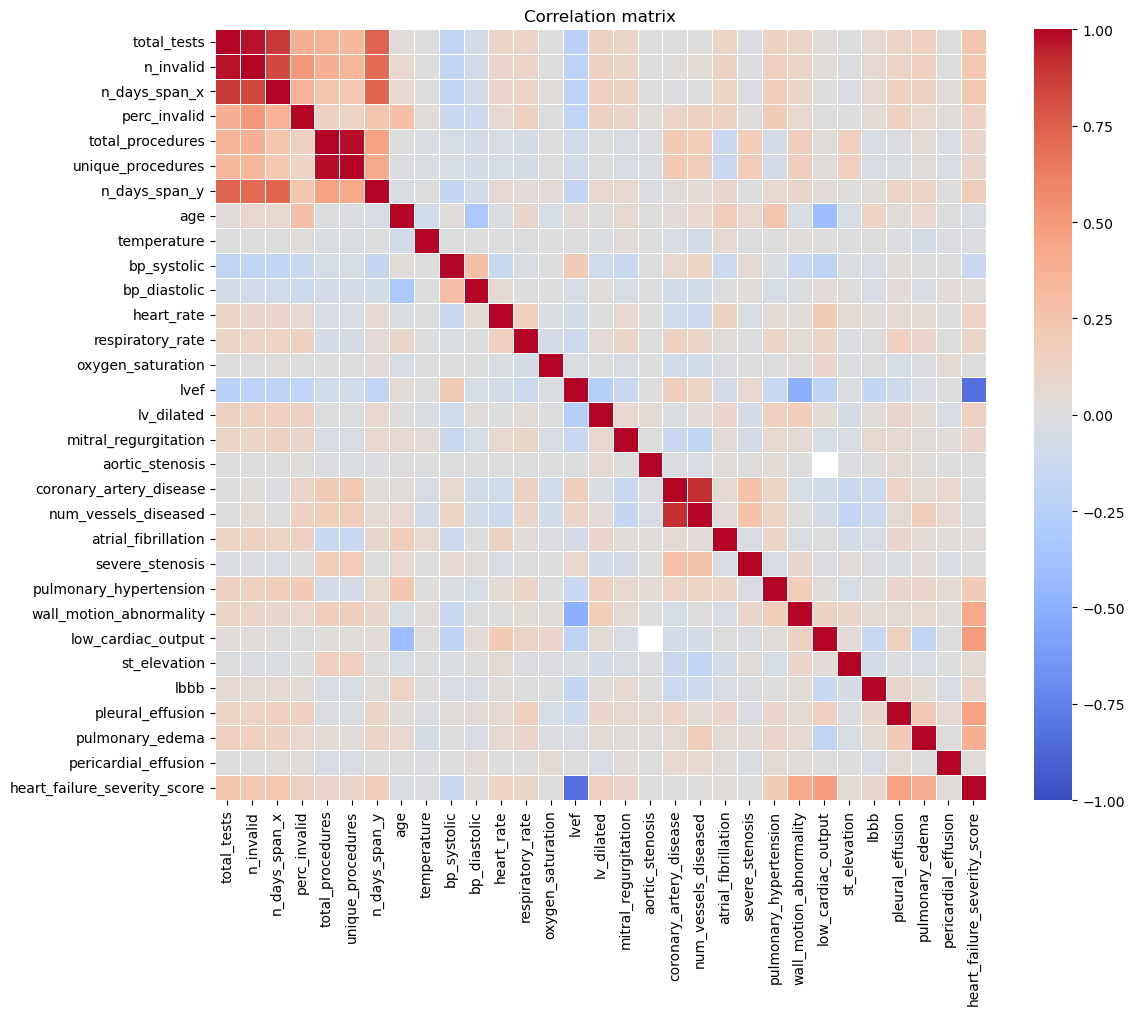

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Heatmap base
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, 
            annot=False,  
            cmap='coolwarm',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5)
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()


As we can see, there are lot of redundant features, so we have to choose which ones to keep and which ones to discard.

In [9]:
# Trova coppie di feature con alta correlazione
def find_high_correlations(corr_matrix, threshold=0.8):
    """
    Find features pairs with correlation > threshold
    """
    high_corr_pairs = []
    
    # Itera sulla matrice triangolare superiore (evita duplicati)
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                high_corr_pairs.append({
                    'feature1': corr_matrix.columns[i],
                    'feature2': corr_matrix.columns[j],
                    'correlation': corr_matrix.iloc[i, j]
                })
    
    return pd.DataFrame(high_corr_pairs).sort_values('correlation', 
                                                       key=abs, 
                                                       ascending=False)

# Trova correlazioni > 0.8
high_corr = find_high_correlations(corr_matrix, threshold=0.8)
print(f"\nHighly correlated features (|r| > 0.8):")
print(high_corr)



Highly correlated features (|r| > 0.8):
                  feature1                      feature2  correlation
3         total_procedures             unique_procedures     0.978497
0              total_tests                     n_invalid     0.970711
5  coronary_artery_disease          num_vessels_diseased     0.908272
1              total_tests                 n_days_span_x     0.889891
2                n_invalid                 n_days_span_x     0.834847
4                     lvef  heart_failure_severity_score    -0.831927
